In [62]:
import pygmt
import requests
import xarray as xr
import numpy as np
import geopandas as gpd
from pathlib import Path
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import colorsys
from matplotlib.patches import Patch
from shapely.geometry import box
import pandas as pd
import io

In [2]:
faults = gpd.read_file("Fallas/Fallas.shp")

# Reproject to geographic coordinates
faults = faults.to_crs("EPSG:4326")

# Select Caribbean region
faults_caribbean = faults.cx[-80:-70, 6:14]

print(faults_caribbean["Tipo"].value_counts())

Tipo
Falla                                        1842
Falla cubierta                                450
Falla inversa o de cabalgamiento              428
Falla de rumbo dextral                        158
Falla inversa o de cabalgamiento cubierta     149
Falla de rumbo sinestral                       77
Falla de rumbo dextral cubierta                68
Falla de rumbo sinestral cubierta              32
Falla inferida                                 27
Lineamiento                                    24
Falla inversa o de cabalgamiento inferida       4
Falla normal inferida                           2
Falla normal cubierta                           2
Falla de rumbo dextral inferida                 2
Falla de rumbo sinestral inferida               1
Falla normal                                    1
Name: count, dtype: int64


In [3]:
plate_boundaries = gpd.read_file(
    "PB2002_boundaries.shp"
)

print(plate_boundaries.columns)
print(plate_boundaries.crs)

Index(['LAYER', 'Name', 'Source', 'PlateA', 'PlateB', 'Type', 'geometry'], dtype='object')
EPSG:4326


In [4]:
plate_boundaries = plate_boundaries.cx[-80:-65, -6:15]

In [5]:
subduction = plate_boundaries[
    plate_boundaries["Type"] == "subduction"
]

# Other plate boundaries
other_boundaries = plate_boundaries[
    plate_boundaries["Type"] != "subduction"
]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pygmt/helpers/decorators.py:598: FutureWarning: The 'rose' parameter has been deprecated since v0.19.0. Use 'Figure.directional_rose' instead.
  return module_func(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pygmt/helpers/decorators.py:598: FutureWarning: The 'map_scale' parameter has been deprecated since v0.19.0. Use 'Figure.scalebar' instead.
  return module_func(*args, **kwargs)


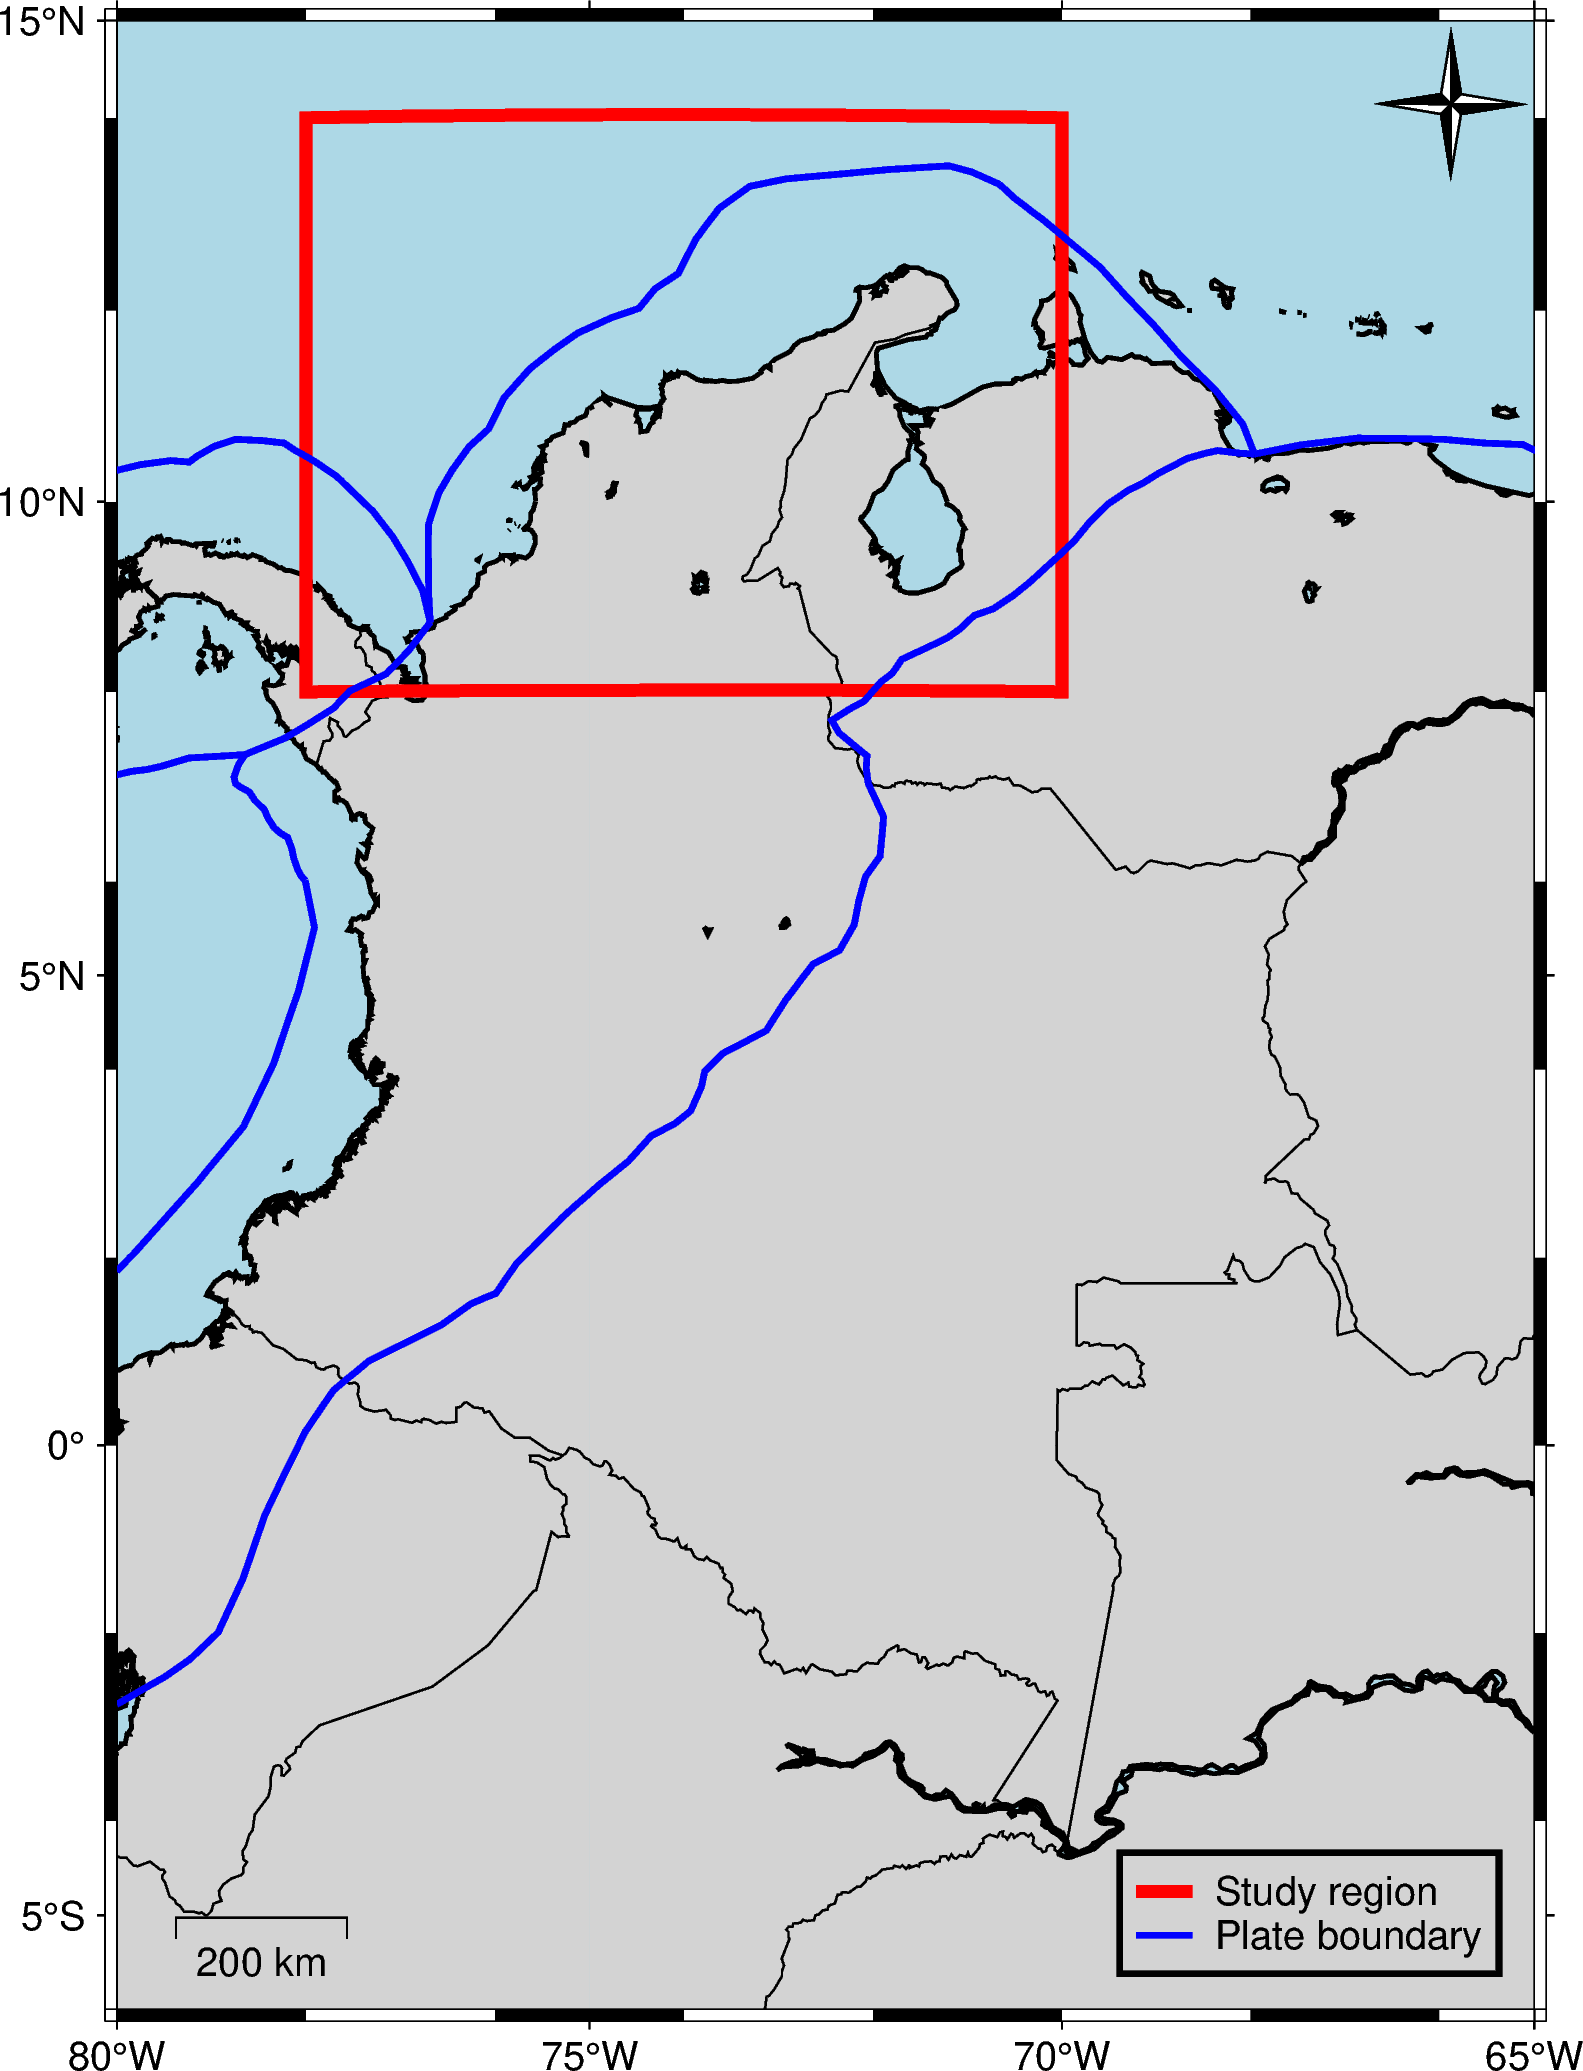

In [6]:
fig = pygmt.Figure()

# Region of interest
region = [-80, -65, -6, 15]

# Base map
fig.coast(
    region=region,
    projection="M12c",
    land="lightgray",
    water="lightblue",
    shorelines="1p,black",
    borders="1/0.5p,black",
    frame=["xaf2", "yaf2"]
)

# Rectangle showing the study region
fig.plot(
    x=[-78, -70, -70, -78, -78],
    y=[8, 8, 14, 14, 8],
    pen="3p,red",
    label="Study region"
)
fig.plot(
    data=plate_boundaries,
    pen="1.5p,blue",
    label="Plate boundary"
)


fig.legend(
    position="JBR+jBR+o0.3c",
    box=True
)

# -----------------------------
# North arrow
# -----------------------------

fig.basemap(
    rose="jTR+w1.2c+f"
)
fig.basemap(
    map_scale="jBL+w200k+u+o0.5c/0.6c"
)

fig.savefig('LocationMap.png')
fig.show()

In [74]:
faults = gpd.read_file("ATA.shp")

# Reproject to geographic coordinates
faults = faults.to_crs("EPSG:4326")

# Select Caribbean region
faults_caribbean = faults.cx[-80:-64, 6:14]


In [75]:
batimetria = "../../../HP2/MapaLocalizacion/HillshadeNonCropped.tif"
pygmt.makecpt(
    cmap="ocean",
    series=[-6000, 0, 500],
    continuous=True
)

In [76]:
focal='jan76_dec25.ndk'

events = []

with open(focal, "r") as f:
    lines = f.readlines()

# Every CMT event = 5 lines
for i in range(0, len(lines), 5):

    line1 = lines[i].split()
    line3 = lines[i + 2].split()
    line4 = lines[i + 3].split()
    line5 = lines[i + 4].split()

    # -------------------------
    # Event information
    # -------------------------
    date = line1[1]
    time = line1[2]

    magnitude = float(line1[6])

    # -------------------------
    # Centroid
    # -------------------------
    latitude = float(line3[3])
    longitude = float(line3[5])
    depth = float(line3[7])

    # -------------------------
    # Moment tensor
    # -------------------------
    exponent = int(line4[0])

    # Scalar moment
    # From the V10 line
    mantissa = float(line5[10])

    # -------------------------
    # Nodal planes
    # -------------------------
    strike1 = float(line5[11])
    dip1 = float(line5[12])
    rake1 = float(line5[13])

    strike2 = float(line5[14])
    dip2 = float(line5[15])
    rake2 = float(line5[16])

    events.append([
        longitude,
        latitude,
        depth,
        strike1,
        dip1,
        rake1,
        strike2,
        dip2,
        rake2,
        mantissa,
        exponent,
        magnitude,
        date,
        time,
    ])


cmt = pd.DataFrame(
    events,
    columns=[
        "longitude",
        "latitude",
        "depth",
        "strike1",
        "dip1",
        "rake1",
        "strike2",
        "dip2",
        "rake2",
        "mantissa",
        "exponent",
        "magnitude",
        "date",
        "time",
    ],
)
cmt

,longitude,latitude,depth,strike1,dip1,rake1,strike2,dip2,rake2,mantissa,exponent,magnitude,date,time
0,-176.96,-29.25,47.8,202.0,30.0,93.0,18.0,60.0,88.0,9.560,26,6.2,1976/01/01,01:29:39.6
1,-75.14,-13.42,85.4,350.0,28.0,-60.0,137.0,66.0,-105.0,3.790,24,6.0,1976/01/05,02:31:36.3
2,159.50,51.45,15.0,206.0,18.0,78.0,39.0,73.0,94.0,1.980,25,5.7,1976/01/06,21:08:19.3
3,167.81,-15.97,173.7,246.0,22.0,-86.0,62.0,68.0,-91.0,3.640,25,6.1,1976/01/09,23:54:35.6
4,-16.29,66.33,15.0,127.0,82.0,173.0,218.0,83.0,9.0,3.300,25,6.0,1976/01/13,13:29:19.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70039,147.66,-57.19,12.0,346.0,71.0,-3.0,77.0,87.0,-161.0,7.166,23,0.0,2025/12/31,04:00:27.8
70040,-120.64,40.60,20.5,231.0,82.0,6.0,140.0,84.0,172.0,3.618,23,0.0,2025/12/31,05:49:31.5
70041,142.87,40.08,28.7,183.0,17.0,71.0,23.0,74.0,96.0,1.455,25,0.0,2025/12/31,14:26:58.0
70042,143.03,40.86,32.6,195.0,29.0,81.0,24.0,61.0,95.0,4.578,23,0.0,2025/12/31,16:30:24.2


In [77]:
cmt_colombia = cmt[
    (cmt["longitude"] >= -80) &
    (cmt["longitude"] <= -67) &
    (cmt["latitude"] >= 6.5) &
    (cmt["latitude"] <= 14.5)
].copy()

print(len(cmt_colombia))

221


In [78]:
print(cmt_colombia["depth"].min())
print(cmt_colombia["depth"].max())

12.0
172.4


In [79]:
print(cmt_colombia["magnitude"].min())
print(cmt_colombia["magnitude"].max())

0.0
6.6


In [80]:
pygmt.makecpt(
    cmap="jet",
    series=[12, 173, 10],
    output="depth.cpt"
)

In [81]:
puntos = pd.DataFrame({
    "longitude": [-67.22, -68.56],
    "latitude": [10.60, 10.37],
})

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pygmt/helpers/decorators.py:598: FutureWarning: The 'rose' parameter has been deprecated since v0.19.0. Use 'Figure.directional_rose' instead.
  return module_func(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pygmt/helpers/decorators.py:598: FutureWarning: The 'map_scale' parameter has been deprecated since v0.19.0. Use 'Figure.scalebar' instead.
  return module_func(*args, **kwargs)


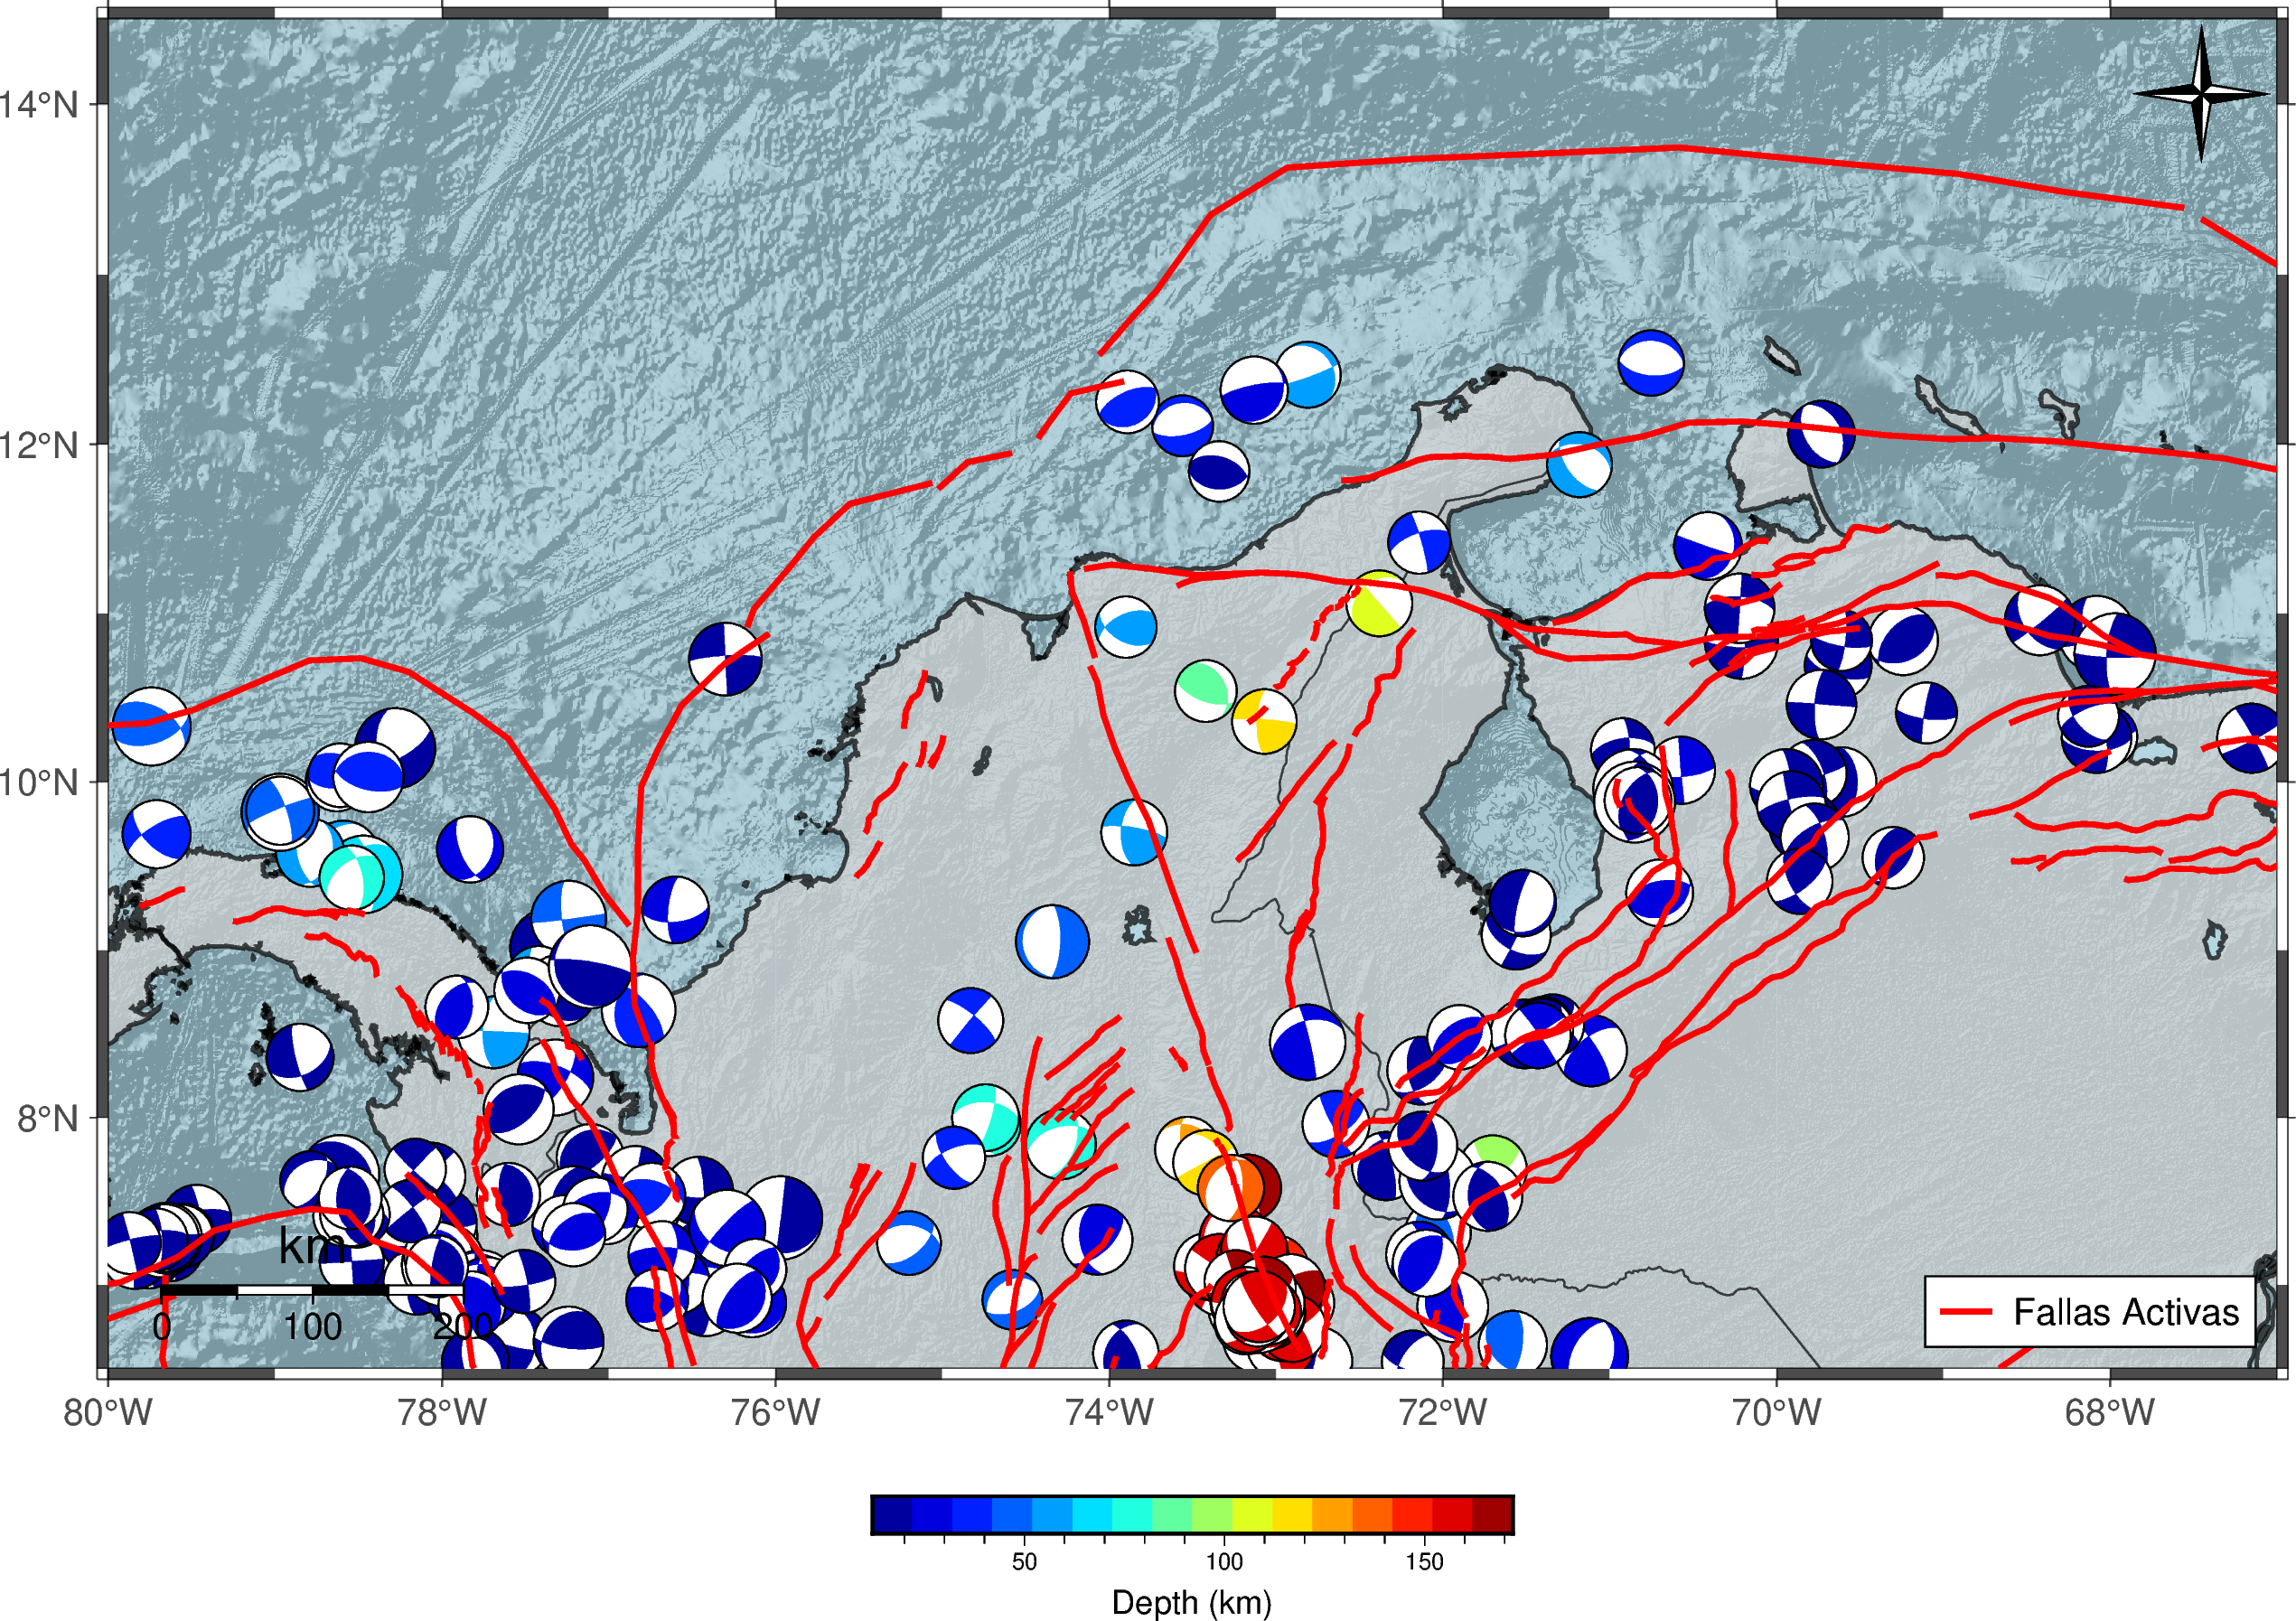

In [89]:
mapaColombia= pygmt.Figure()

region_colombia = [-80, -67, 6.5, 14.5]

mapaColombia.grdimage(
    grid=batimetria,
    region=region_colombia,
    projection="M8i",
)


mapaColombia.coast(
    region=region_colombia,
    projection="M8i",
    frame=True,
    land="lightgray",
    water="lightblue",
    shorelines="1p,black",
    borders="1/0.5p,black",
    transparency=30)

mapaColombia.meca(
    spec=cmt_colombia,
    convention="gcmt",
    scale="0.6c",
    cmap="depth.cpt",
    pen="0.4p,black",
    extension_fill="white",
)

mapaColombia.colorbar(
    cmap="depth.cpt",
    frame='af+lDepth (km)',
    position="JBC+w6c/0.35c+o0c/1.2c",
)

legend_spec = io.StringIO("""
H 10p,Helvetica-Bold Magnitude
S 0.4c c 0.25c black 0.4p,black 0.6c M 5
S 0.4c c 0.45c black 0.4p,black 0.6c M 6
S 0.4c c 0.70c black 0.4p,black 0.6c M 7
""")



mapaColombia.plot(data=faults_caribbean,pen="1.5p,red",label='Fallas Activas')

mapaColombia.basemap(
    rose="jTR+w1.2c+f"
)
mapaColombia.basemap(
    map_scale="jBL+w200k+f+l+o0.5c/0.6c"
)
mapaColombia.legend(
    position="JBR+jBR+o0.2c/0.2c",
    box="+gwhite+p0.5p",
)

mapaColombia.savefig('mapa_fallas.png')
mapaColombia.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pygmt/helpers/decorators.py:598: FutureWarning: The 'rose' parameter has been deprecated since v0.19.0. Use 'Figure.directional_rose' instead.
  return module_func(*args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pygmt/helpers/decorators.py:598: FutureWarning: The 'map_scale' parameter has been deprecated since v0.19.0. Use 'Figure.scalebar' instead.
  return module_func(*args, **kwargs)


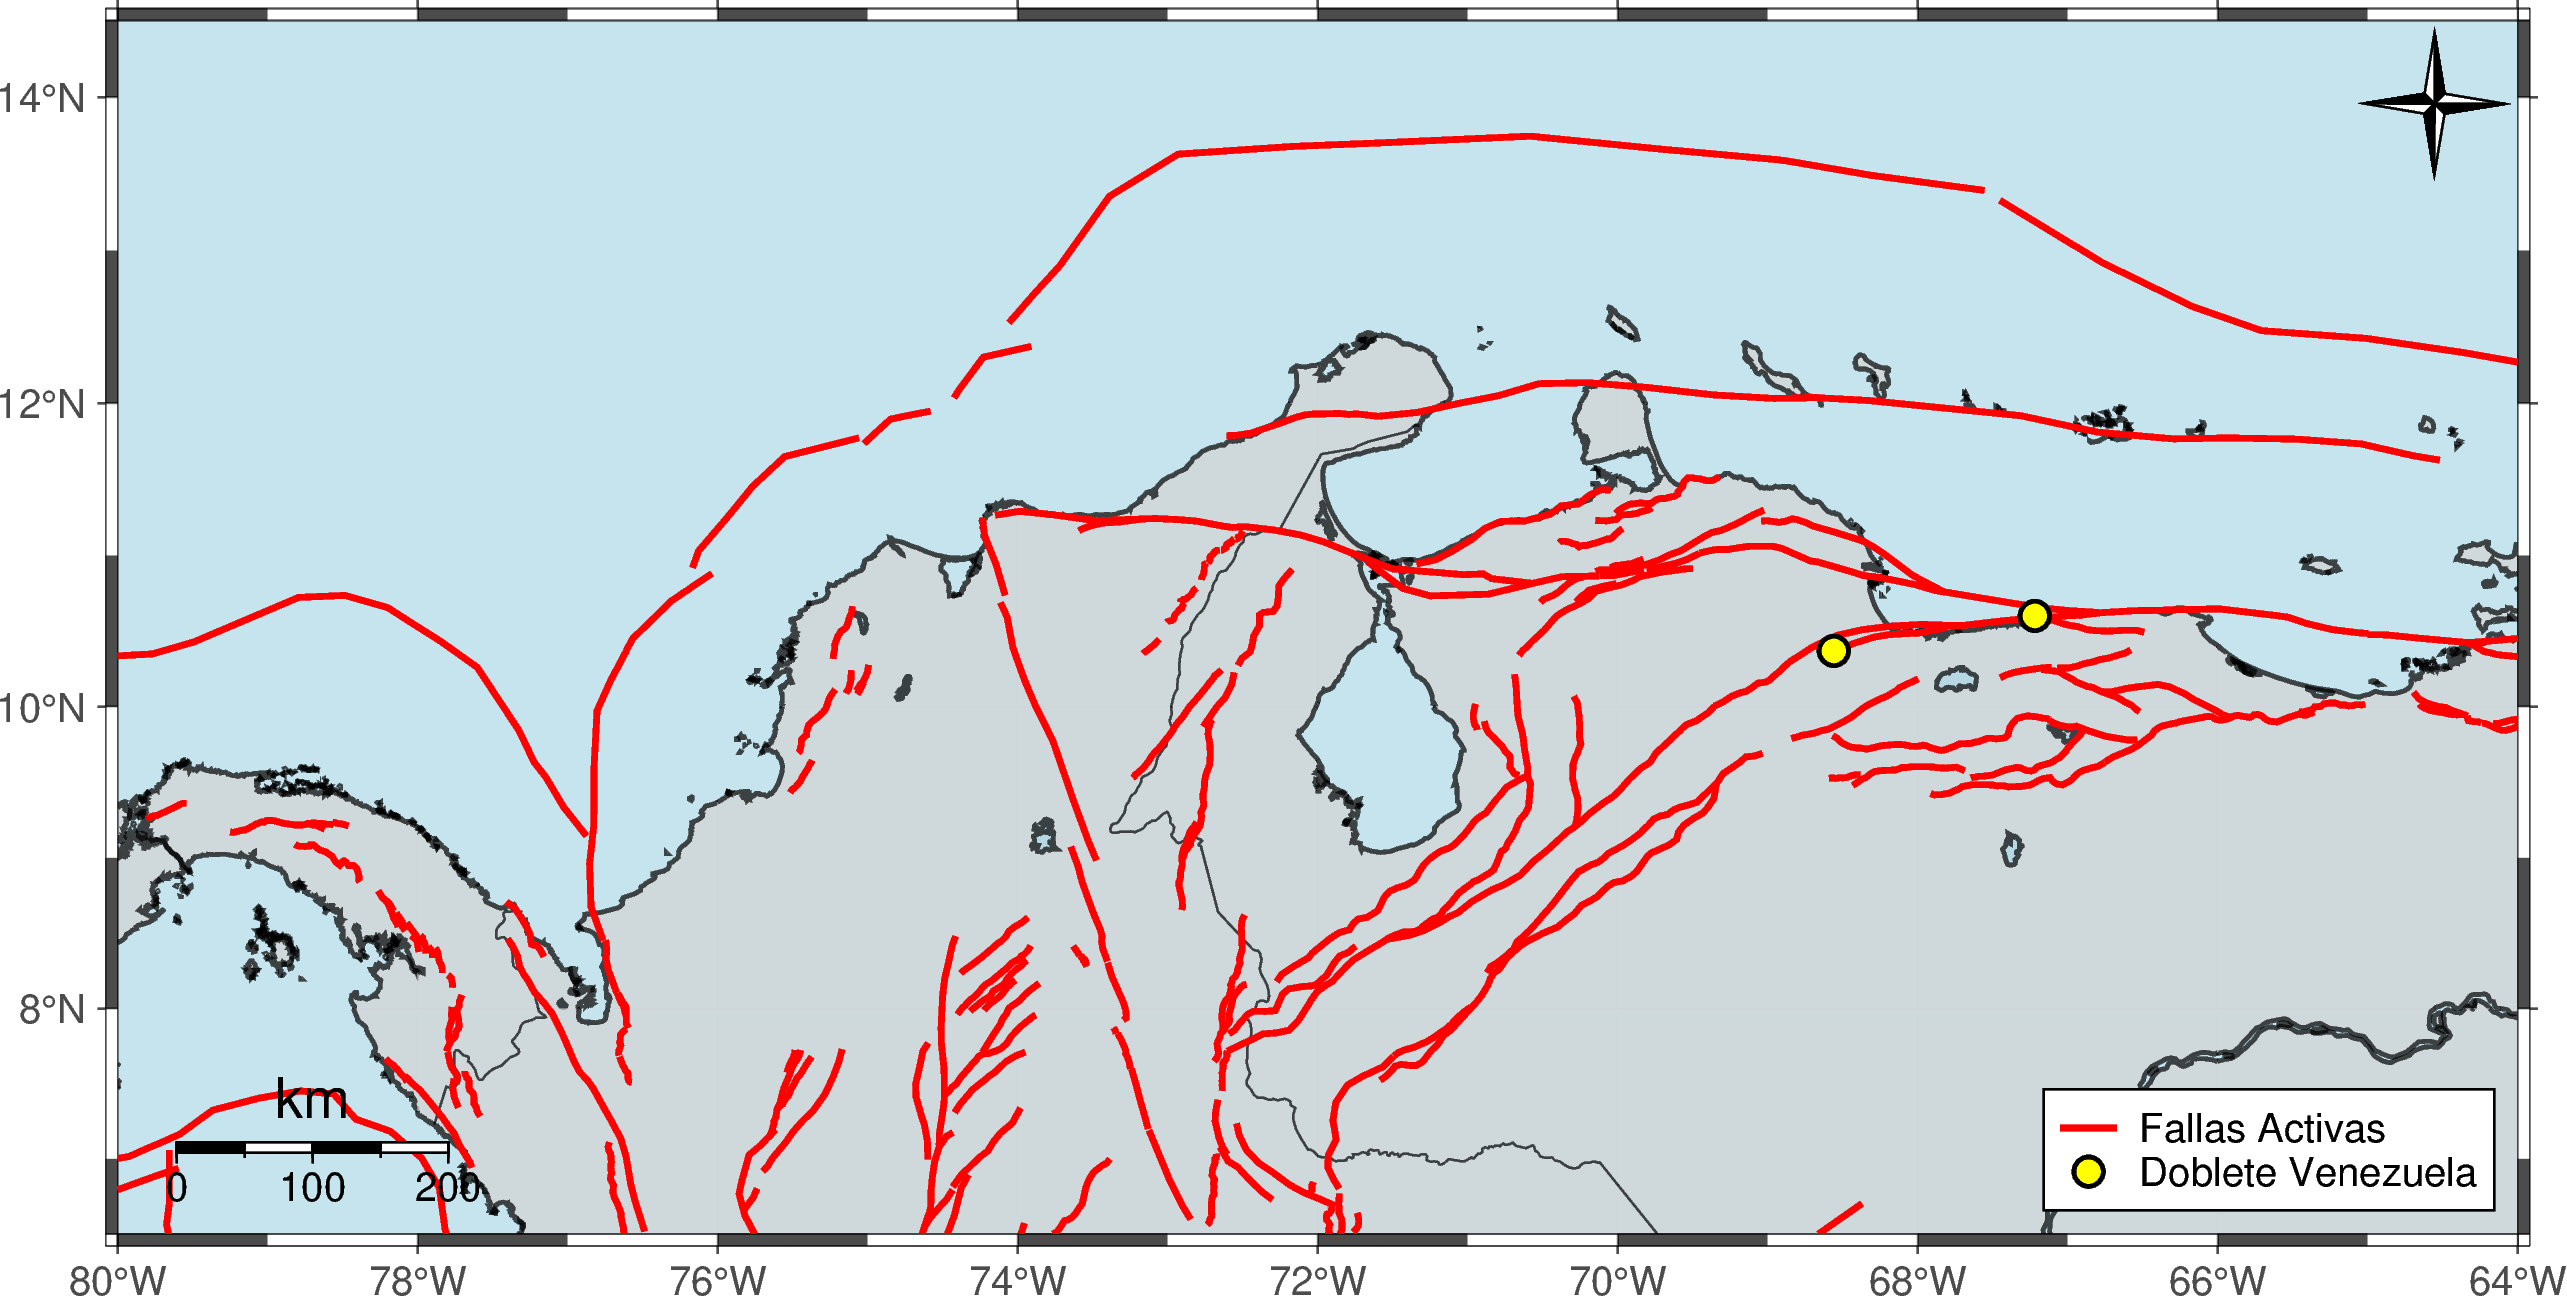

In [90]:
mapaColombia= pygmt.Figure()

region_colombia = [-80, -64, 6.5, 14.5]

#mapaColombia.grdimage(
#    grid=batimetria,
#    region=region_colombia,
#    projection="M8i",
#)


mapaColombia.coast(
    region=region_colombia,
    projection="M8i",
    frame=True,
    land="lightgray",
    water="lightblue",
    shorelines="1p,black",
    borders="1/0.5p,black",
    transparency=30)
mapaColombia.plot(data=faults_caribbean,pen="1.5p,red",label='Fallas Activas')


mapaColombia.plot(
    x=puntos["longitude"],
    y=puntos["latitude"],
    style="c0.25c",
    fill="yellow",
    pen="1p,black",
    label='Doblete Venezuela'
)


mapaColombia.basemap(
    rose="jTR+w1.2c+f"
)
mapaColombia.basemap(
    map_scale="jBL+w200k+f+l+o0.5c/0.6c"
)

mapaColombia.legend(
    position="JBR+jBR+o0.2c/0.2c",
    box="+gwhite+p0.5p",
)

mapaColombia.savefig('mapaVen_fallas.png')
mapaColombia.show()

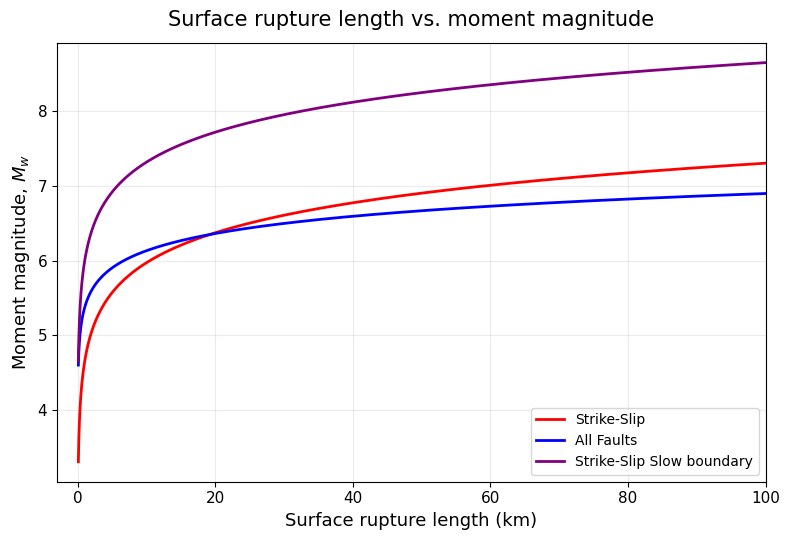

In [129]:
length=np.linspace(0.1,100,1000000)
M_A11 = 3.07 + (4/3)*np.log10(15*length)
M_A22=4.18+2/3*np.log(15)+4/3*np.log10(length)
M_A21 = (((np.log10(15 * length * 1e6) + 13.79) / 0.87)- 16.05) / 1.5


fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot(length, M_A11, linewidth=2,label='Strike-Slip',color='red')
ax.plot(length, M_A21, linewidth=2,label='All Faults',color='blue')
ax.plot(length, M_A22, linewidth=2,label='Strike-Slip Slow boundary',color='purple')


ax.set_xlabel("Surface rupture length (km)", fontsize=13)
ax.set_ylabel(r"Moment magnitude, $M_w$", fontsize=13)

ax.set_title("Surface rupture length vs. moment magnitude", fontsize=15, pad=12)

ax.set_xlim(-3, 100)
#ax.set_ylim(3.5, 7.5)

ax.grid(True, alpha=0.25)
ax.tick_params(axis="both", labelsize=11)


ax.legend()

plt.tight_layout()
plt.savefig('EmpRelati.png')
plt.show()

In [144]:
length = np.linspace(1, 100, 1000)

# -------------------------
# A11 - Hanks & Bakun (2008)
# -------------------------

A = 15 * length  # km²

M_A11 = np.where(
    A <= 537,
    np.log10(A) + 3.98,
    (4/3) * np.log10(A) + 3.07
)


# -------------------------
# A21 - Yen & Ma (2011)
# -------------------------

Ae = 15 * length * 1e6  # m²

log_M0_A21 = (
    np.log10(Ae) + 13.79
) / 0.87

M_A21 = (
    log_M0_A21 - 16.05
) / 1.5


# -------------------------
# A22 - Stirling et al. (2008)
# -------------------------

W = 15  # km

M_A22 = (
    4.18
    + (2/3) * np.log10(W)
    + (4/3) * np.log10(length)
)

M_all=5.08+1.16*np.log10(length)
M_ss=5.16+1.12*np.log10(length)
M_r=5+1.22*np.log10(length)
M_n=4.86+1.32*np.log10(length)
M_subduc = (np.log10(length) + 2.81) / 0.62

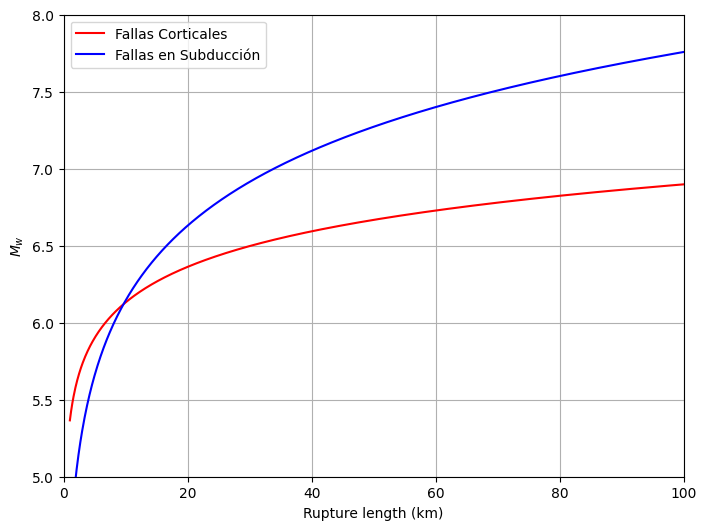

In [146]:
plt.figure(figsize=(8,6))

plt.plot(length, M_A21, label="Fallas Corticales",color='red')
plt.plot(length, M_subduc, label="Fallas en Subducción",color='blue')

#plt.plot(length, M_A21, label="A21 All Faults(YM)")


plt.xlabel("Rupture length (km)")
plt.ylabel("$M_w$")
plt.xlim(0, 100)
plt.ylim(5, 8)



plt.legend()
plt.grid()

plt.show()